# Calibrated Confidence Tier Analysis

Stratifies cohort predictions into precision-targeted confidence tiers using TrunCat's calibrated probabilities. The thresholds correspond to expected precision rates that are guaranteed by calibration (ECE = 0.022 on TOPMed OOF).

**Inputs:** TrunCat predictions for each cohort. ClinVar is loaded as one combined cohort rather than split into P/LP and VUS. Each file must have a column with the escape probability (default `truncat_prob`) and ideally a stable variant ID. Path templates are configurable below.

**Outputs:**
- `outputs/tier_analysis/cohort_tier_breakdown.tsv` — count and proportion per tier per cohort
- `outputs/tier_analysis/cohort_tier_pivot.tsv` — wide format suitable for direct paste into manuscript table
- `outputs/tier_analysis/figs/tier_stacked_bar.png` (+ .pdf) — stacked bar chart of tier composition by cohort
- `outputs/tier_analysis/figs/tier_grouped_bar.png` (+ .pdf) — grouped bar chart for cleaner cohort comparison

**Tier definitions (calibration-derived precision targets):**
| Tier | Threshold | Expected precision |
|---|---|---|
| High-confidence escape | p ≥ 0.80 | ~80% |
| Probable escape | 0.65 ≤ p < 0.80 | 65–80% |
| Uncertain | 0.35 ≤ p < 0.65 | within 15pp of chance |
| Probable sensitive | 0.20 ≤ p < 0.35 | 65–80% |
| High-confidence sensitive | p < 0.20 | >80% |

## 1. Configuration

In [12]:
from pathlib import Path

# --- Paths -----------------------------------------------------------------
BASE_DIR = Path("/Users/jschmidt3/NMDpredictionmodel")

# Update these paths to point at the actual TrunCat-scored cohort files.
# If a cohort doesn't have a file yet, leave the path as None and it will be skipped.
COHORT_PATHS = {
    "gnomAD": BASE_DIR / "Model" / "TrunCat" / "predict" / "gnomad_predictions.csv",
    
    # ClinVar is analyzed as one combined cohort here, not split into P/LP and VUS.   
    "ClinVar":     BASE_DIR / "Model" / "TrunCat" / "predict" / "clinvar_predictions.csv",
    "GREGoR":      BASE_DIR / "Model" / "TrunCat" / "predict" / "gregor_predictions.csv",
}

# OOF file used as the calibration reference (so we can include TOPMed in the table
# with empirical escape rates per tier — a useful sanity check)
TOPMED_OOF_PATH = BASE_DIR / "Model" / "TrunCat" / "results" / "cv_predictions_with_ids.csv"

# --- Output ---------------------------------------------------------------
OUTPUT_DIR = BASE_DIR / "Model" / "TrunCat" / "results" / "tier_analysis"
FIG_DIR = OUTPUT_DIR / "figs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Column names ---------------------------------------------------------
# The probability column in each cohort file. If different files use different
# names, you can override per-cohort below in load_cohort().
PROB_COL = "escape_probability"
OOF_PROB_COL = "oof_prob"
OOF_LABEL_COL = "y_true"

# --- Tier thresholds (precision-targeted) ---------------------------------
# Edit these to retune. They are anchored to your calibration plot:
# at p ≥ 0.80, observed escape rate is ~0.80, etc.
TIER_THRESHOLDS = [
    ("High-confidence sensitive", -float("inf"), 0.20),
    ("Probable sensitive",        0.20,           0.35),
    ("Uncertain",                 0.35,           0.65),
    ("Probable escape",           0.65,           0.80),
    ("High-confidence escape",    0.80,           float("inf")),
]
TIER_ORDER = [name for name, _, _ in TIER_THRESHOLDS]

SAVE_OUTPUTS = True

for cohort, path in COHORT_PATHS.items():
    print(f"  {cohort:14s} -> {path}")

  gnomAD         -> /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/predict/gnomad_predictions.csv
  ClinVar        -> /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/predict/clinvar_predictions.csv
  GREGoR         -> /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/predict/gregor_predictions.csv


## 2. Tier-assignment helpers

In [13]:
import pandas as pd
import numpy as np

def assign_tier(prob, thresholds=TIER_THRESHOLDS):
    """Map a probability (or array of probabilities) to a tier label."""
    arr = np.asarray(prob, dtype=float)
    out = np.empty(arr.shape, dtype=object)
    out[:] = "Unknown"  # for NaN inputs
    valid = ~np.isnan(arr)
    for name, lo, hi in thresholds:
        mask = valid & (arr >= lo) & (arr < hi)
        out[mask] = name
    return out


def tier_breakdown(probs, cohort_name, labels=None):
    """Return one row per tier with count, % of cohort, and (if labels given) empirical escape rate."""
    probs = np.asarray(probs, dtype=float)
    valid = ~np.isnan(probs)
    probs = probs[valid]
    if labels is not None:
        labels = np.asarray(labels)[valid]

    tiers = assign_tier(probs)
    n_total = len(probs)
    rows = []
    for name, lo, hi in TIER_THRESHOLDS:
        mask = tiers == name
        n = int(mask.sum())
        row = {
            "cohort": cohort_name,
            "tier": name,
            "threshold_low": lo if np.isfinite(lo) else None,
            "threshold_high": hi if np.isfinite(hi) else None,
            "n": n,
            "pct": (n / n_total * 100) if n_total else 0.0,
            "mean_predicted_prob": float(probs[mask].mean()) if n else np.nan,
        }
        if labels is not None and n > 0:
            row["empirical_escape_rate"] = float(labels[mask].mean())
        elif labels is not None:
            row["empirical_escape_rate"] = np.nan
        rows.append(row)
    rows.append({
        "cohort": cohort_name,
        "tier": "TOTAL",
        "threshold_low": None,
        "threshold_high": None,
        "n": n_total,
        "pct": 100.0,
        "mean_predicted_prob": float(probs.mean()) if n_total else np.nan,
        "empirical_escape_rate": float(labels.mean()) if labels is not None and n_total else np.nan,
    })
    return pd.DataFrame(rows)

## 3. Load cohorts and TOPMed reference

TOPMed is included as a sanity check: because we have ground-truth labels, we can verify the empirical escape rate per tier matches the expected precision (the calibration claim restated cohort-by-cohort).

In [14]:
def load_cohort(path, prob_col=PROB_COL):
    if path is None or not Path(path).exists():
        print(f"  [skip] {path} not found")
        return None
    df = pd.read_csv(path, low_memory=False)
    if prob_col not in df.columns:
        # Fall back to common alternatives
        for alt in ("oof_prob", "prob", "probability", "score", "truncat_prediction"):
            if alt in df.columns:
                prob_col = alt
                break
        else:
            raise ValueError(f"{path.name} missing probability column. Has: {list(df.columns)}")
    return df, prob_col

all_breakdowns = []

# --- TOPMed (with labels) -----------------------------------------------
if TOPMED_OOF_PATH.exists():
    topmed = pd.read_csv(TOPMED_OOF_PATH, low_memory=False)
    topmed = topmed.dropna(subset=[OOF_PROB_COL, OOF_LABEL_COL])
    bd = tier_breakdown(
        topmed[OOF_PROB_COL].values,
        cohort_name="TOPMed (OOF, reference)",
        labels=topmed[OOF_LABEL_COL].values,
    )
    all_breakdowns.append(bd)
    print(f"  TOPMed: {len(topmed):,} variants loaded")
else:
    print(f"  [skip] TOPMed OOF not found at {TOPMED_OOF_PATH}")

# --- Application cohorts (no labels) ------------------------------------
for cohort_name, path in COHORT_PATHS.items():
    result = load_cohort(path)
    if result is None:
        continue
    df, prob_col = result
    bd = tier_breakdown(df[prob_col].values, cohort_name=cohort_name, labels=None)
    all_breakdowns.append(bd)
    print(f"  {cohort_name}: {len(df):,} variants loaded (prob_col='{prob_col}')")

if not all_breakdowns:
    raise RuntimeError("No cohorts loaded — check COHORT_PATHS and TOPMED_OOF_PATH.")

breakdown = pd.concat(all_breakdowns, ignore_index=True)
breakdown.head(20)

  TOPMed: 5,749 variants loaded
  gnomAD: 137,857 variants loaded (prob_col='escape_probability')
  ClinVar: 30,128 variants loaded (prob_col='escape_probability')
  GREGoR: 2,548 variants loaded (prob_col='escape_probability')


,cohort,tier,threshold_low,threshold_high,n,pct,mean_predicted_prob,empirical_escape_rate
0,"TOPMed (OOF, reference)",High-confidence sensitive,NaN,0.20,786,13.671943,0.153686,0.118321
1,"TOPMed (OOF, reference)",Probable sensitive,0.20,0.35,1679,29.205079,0.273278,0.256700
2,"TOPMed (OOF, reference)",Uncertain,0.35,0.65,1770,30.787963,0.474915,0.503390
3,"TOPMed (OOF, reference)",Probable escape,0.65,0.80,833,14.489476,0.733095,0.758703
4,"TOPMed (OOF, reference)",High-confidence escape,0.80,NaN,681,11.845538,0.840930,0.838473
5,"TOPMed (OOF, reference)",TOTAL,NaN,NaN,5749,100.000000,0.452874,0.455384
6,gnomAD,High-confidence sensitive,NaN,0.20,46354,33.624698,0.109535,NaN
7,gnomAD,Probable sensitive,0.20,0.35,24616,17.856184,0.268765,NaN
8,gnomAD,Uncertain,0.35,0.65,27454,19.914839,0.486525,NaN
9,gnomAD,Probable escape,0.65,0.80,12550,9.103636,0.729390,NaN


## 4. Save tier breakdown tables

In [15]:
# Long-format table (one row per tier per cohort)
if SAVE_OUTPUTS:
    breakdown.to_csv(OUTPUT_DIR / "cohort_tier_breakdown.tsv", sep="\t", index=False)
    print(f"[write] {OUTPUT_DIR / 'cohort_tier_breakdown.tsv'}")

# Wide-format pivot for direct manuscript table use
tier_only = breakdown[breakdown["tier"] != "TOTAL"]
pivot_pct = (
    tier_only
    .pivot(index="cohort", columns="tier", values="pct")
    .reindex(columns=TIER_ORDER)
    .round(1)
)
pivot_n = (
    tier_only
    .pivot(index="cohort", columns="tier", values="n")
    .reindex(columns=TIER_ORDER)
    .astype(int)
)
pivot_pct["N total"] = pivot_n.sum(axis=1)

if SAVE_OUTPUTS:
    pivot_pct.to_csv(OUTPUT_DIR / "cohort_tier_pivot.tsv", sep="\t")
    print(f"[write] {OUTPUT_DIR / 'cohort_tier_pivot.tsv'}")

print("\nTier composition by cohort (% of cohort variants):")
pivot_pct

[write] /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/tier_analysis/cohort_tier_breakdown.tsv
[write] /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/tier_analysis/cohort_tier_pivot.tsv

Tier composition by cohort (% of cohort variants):


tier,High-confidence sensitive,Probable sensitive,Uncertain,Probable escape,High-confidence escape,N total
cohort,,,,,,
ClinVar,37.4,19.6,21.9,7.8,13.2,30128
GREGoR,33.8,13.5,15.9,9.1,27.7,2548
"TOPMed (OOF, reference)",13.7,29.2,30.8,14.5,11.8,5749
gnomAD,33.6,17.9,19.9,9.1,19.5,137857


## 5. Calibration sanity check on TOPMed tiers

On the labeled TOPMed OOF set, the empirical escape rate per tier should sit near the midpoint of the tier's predicted-probability range. Big deviations would suggest the tier thresholds are poorly placed for this calibration.

In [16]:
topmed_check = breakdown[
    (breakdown["cohort"] == "TOPMed (OOF, reference)") &
    (breakdown["tier"] != "TOTAL")
].copy()

if len(topmed_check) > 0:
    cols = ["tier", "n", "pct", "mean_predicted_prob", "empirical_escape_rate"]
    topmed_check["calibration_gap"] = (
        topmed_check["empirical_escape_rate"] - topmed_check["mean_predicted_prob"]
    )
    print("TOPMed OOF: per-tier mean predicted prob vs empirical escape rate")
    print("(positive gap = model underestimates; negative gap = model overestimates)")
    print(topmed_check[cols + ["calibration_gap"]].round(3).to_string(index=False))
else:
    print("TOPMed OOF not loaded — skipping calibration sanity check.")

TOPMed OOF: per-tier mean predicted prob vs empirical escape rate
(positive gap = model underestimates; negative gap = model overestimates)
                     tier    n    pct  mean_predicted_prob  empirical_escape_rate  calibration_gap
High-confidence sensitive  786 13.672                0.154                  0.118           -0.035
       Probable sensitive 1679 29.205                0.273                  0.257           -0.017
                Uncertain 1770 30.788                0.475                  0.503            0.028
          Probable escape  833 14.489                0.733                  0.759            0.026
   High-confidence escape  681 11.846                0.841                  0.838           -0.002


## 6. Visualizations

Two views: stacked bar (composition) and grouped bar (cohort-by-cohort comparison within tier).

[write] /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/tier_analysis/figs/tier_stacked_bar.png (+ .pdf)


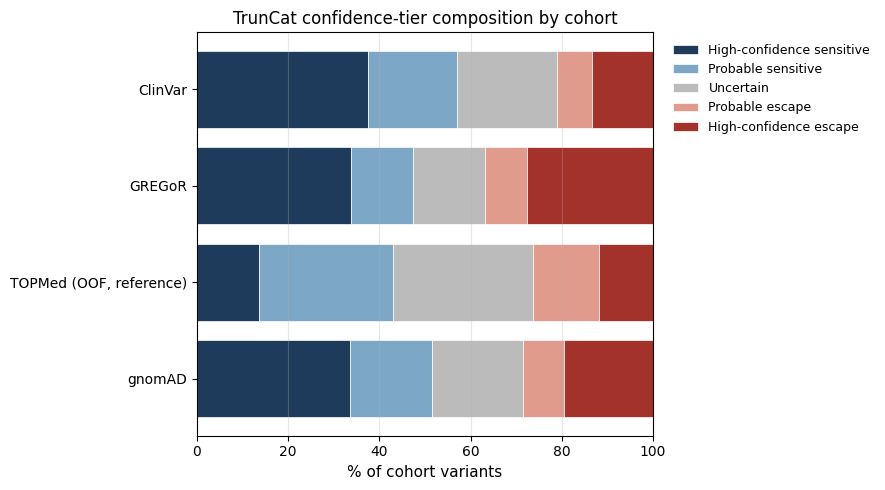

[write] /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/tier_analysis/figs/tier_grouped_bar.png (+ .pdf)


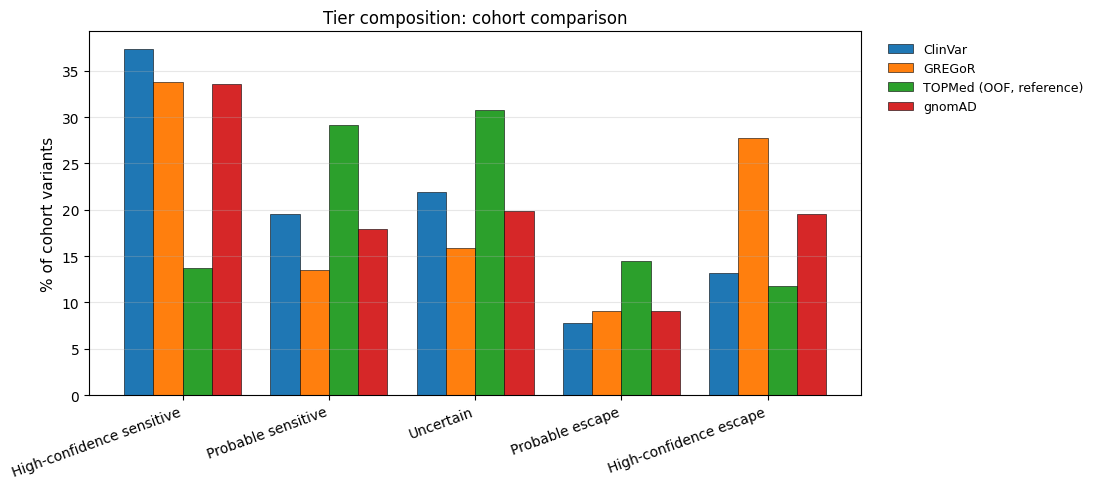

In [17]:
import matplotlib.pyplot as plt

# A 5-color sequential palette: deep blue (sensitive) -> gray (uncertain) -> deep red (escape)
TIER_COLORS = {
    "High-confidence sensitive": "#1f3b5b",
    "Probable sensitive":        "#7da7c7",
    "Uncertain":                 "#bbbbbb",
    "Probable escape":           "#e09b8c",
    "High-confidence escape":    "#a3322a",
}

# --- Stacked bar (composition) -----------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
cohort_order = list(pivot_pct.index)
bottom = np.zeros(len(cohort_order))
for tier in TIER_ORDER:
    vals = pivot_pct[tier].values
    ax.barh(cohort_order, vals, left=bottom, color=TIER_COLORS[tier],
            edgecolor="white", linewidth=0.5, label=tier)
    bottom += vals
ax.set_xlim(0, 100)
ax.set_xlabel("% of cohort variants", fontsize=11)
ax.set_title("TrunCat confidence-tier composition by cohort", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, frameon=False)
ax.invert_yaxis()  # cohorts read top-to-bottom in input order
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(FIG_DIR / "tier_stacked_bar.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "tier_stacked_bar.pdf", bbox_inches="tight")
    print(f"[write] {FIG_DIR / 'tier_stacked_bar.png'} (+ .pdf)")
plt.show()

# --- Grouped bar (cohort comparison within tier) -----------------------
fig, ax = plt.subplots(figsize=(11, 5))
n_cohorts = len(cohort_order)
x = np.arange(len(TIER_ORDER))
width = 0.8 / n_cohorts
cohort_colors = plt.cm.tab10.colors[:n_cohorts]
for i, cohort in enumerate(cohort_order):
    offset = (i - (n_cohorts - 1) / 2) * width
    ax.bar(x + offset, pivot_pct.loc[cohort, TIER_ORDER].values,
           width=width, label=cohort, color=cohort_colors[i], edgecolor="black",
           linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(TIER_ORDER, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("% of cohort variants", fontsize=11)
ax.set_title("Tier composition: cohort comparison", fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(FIG_DIR / "tier_grouped_bar.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "tier_grouped_bar.pdf", bbox_inches="tight")
    print(f"[write] {FIG_DIR / 'tier_grouped_bar.png'} (+ .pdf)")
plt.show()

## 7. Pairwise tier enrichment (optional)

For a quantitative comparison, this section compares the fraction of variants in a selected tier between cohorts. ClinVar is now treated as one combined cohort, so the old ClinVar VUS vs ClinVar P/LP comparisons have been removed.

Edit the comparisons below to taste.


In [18]:
from scipy.stats import fisher_exact

# Comparisons of interest: (cohort_a, cohort_b, tier_to_compare)
# ClinVar is a single combined cohort in this notebook.
COMPARISONS = [
    ("GREGoR",      "ClinVar", "High-confidence escape"),
    ("GREGoR",      "ClinVar", "Probable escape"),
    ("gnomAD", "ClinVar", "High-confidence escape"),
    ("gnomAD", "ClinVar", "Probable escape"),
]

enrichment_rows = []
for cohort_a, cohort_b, tier in COMPARISONS:
    if cohort_a not in pivot_n.index or cohort_b not in pivot_n.index:
        continue
    a_in = int(pivot_n.loc[cohort_a, tier])
    a_out = int(pivot_n.loc[cohort_a].sum() - a_in)
    b_in = int(pivot_n.loc[cohort_b, tier])
    b_out = int(pivot_n.loc[cohort_b].sum() - b_in)

    table = [[a_in, a_out], [b_in, b_out]]
    odds, p = fisher_exact(table, alternative="two-sided")

    pct_a = pivot_pct.loc[cohort_a, tier]
    pct_b = pivot_pct.loc[cohort_b, tier]
    fold = (pct_a / pct_b) if pct_b > 0 else np.nan

    enrichment_rows.append({
        "comparison": f"{cohort_a} vs {cohort_b}",
        "tier": tier,
        f"pct_{cohort_a}": pct_a,
        f"pct_{cohort_b}": pct_b,
        "fold_change": fold,
        "odds_ratio": odds,
        "fisher_p": p,
    })

enrichment_df = pd.DataFrame(enrichment_rows)
if SAVE_OUTPUTS and len(enrichment_df) > 0:
    enrichment_df.to_csv(OUTPUT_DIR / "tier_enrichment.tsv", sep="\t", index=False)
    print(f"[write] {OUTPUT_DIR / 'tier_enrichment.tsv'}")

if len(enrichment_df) > 0:
    print("\nTier enrichment comparisons:")
    print(enrichment_df.round(3).to_string(index=False))
else:
    print("No comparisons computed (cohorts may not be loaded).")


[write] /Users/jschmidt3/NMDpredictionmodel/Model/TrunCat/results/tier_analysis/tier_enrichment.tsv

Tier enrichment comparisons:
       comparison                   tier  pct_GREGoR  pct_ClinVar  fold_change  odds_ratio  fisher_p  pct_gnomAD
GREGoR vs ClinVar High-confidence escape        27.7         13.2        2.098       2.515     0.000         NaN
GREGoR vs ClinVar        Probable escape         9.1          7.8        1.167       1.174     0.029         NaN
gnomAD vs ClinVar High-confidence escape         NaN         13.2        1.477       1.590     0.000        19.5
gnomAD vs ClinVar        Probable escape         NaN          7.8        1.167       1.179     0.000         9.1


## 8. Manuscript-ready takeaways

Once this notebook runs end-to-end, the tier table and enrichment numbers can directly feed into the application-cohort sentence in the abstract. Example reframe (using placeholder numbers):

> "TrunCat assigned calibrated escape probabilities to variants in gnomAD v4.1 (n = 137,857), combined ClinVar stop-gain variants (n = [N]), and the GREGoR rare-disease cohort. Stratifying by calibration-derived confidence tiers, ClinVar variants showed [X]% high-confidence escape predictions (p ≥ 0.80), while GREGoR and gnomAD showed [Y]% and [Z]%, respectively."

The TOPMed sanity check (section 5) confirms that empirical escape rates per tier match the predicted probability midpoints — i.e., calibration holds tier-by-tier, not just on average. That's worth one supplementary methods sentence.
